In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler 
from sklearn.decomposition import PCA 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier


In [114]:
dt= pd.read_csv("train.csv")
dt

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Expected,Id
0,0,143733,False,0.439,0.196,0,-16.093,1,0.0601,0.880000,0.00000,0.0513,0.525,129.581,4,jazz,4271
1,0,261562,False,0.627,0.876,11,-4.391,0,0.0324,0.015900,0.00000,0.0665,0.418,111.950,4,electronic,2078
2,63,190131,False,0.767,0.869,2,-3.381,0,0.0908,0.140000,0.00000,0.2210,0.751,98.208,4,hip-hop,4921
3,48,201440,False,0.374,0.183,9,-13.225,1,0.0281,0.897000,0.03870,0.1090,0.134,82.042,4,acoustic,4206
4,0,168552,True,0.423,0.721,0,-8.070,1,0.1650,0.007920,0.00000,0.3800,0.382,161.926,4,rock,2423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4195,38,451750,False,0.764,0.873,10,-7.985,0,0.0466,0.000117,0.74400,0.6150,0.169,124.025,4,electronic,5157
4196,64,182640,True,0.598,0.804,2,-5.390,1,0.1230,0.057600,0.00000,0.2520,0.322,139.737,4,hip-hop,1084
4197,82,354320,False,0.414,0.404,0,-9.928,0,0.0499,0.271000,0.00000,0.3000,0.224,71.105,4,rock,2288
4198,0,192160,False,0.320,0.210,6,-15.231,1,0.0345,0.920000,0.00008,0.1380,0.208,73.196,5,jazz,1824


In [115]:
#vemos los NaN
dt.isna().mean()

popularity          0.0
duration_ms         0.0
explicit            0.0
danceability        0.0
energy              0.0
key                 0.0
loudness            0.0
mode                0.0
speechiness         0.0
acousticness        0.0
instrumentalness    0.0
liveness            0.0
valence             0.0
tempo               0.0
time_signature      0.0
Expected            0.0
Id                  0.0
dtype: float64

In [116]:
#vemos tipo de datos
dt.dtypes

popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
Expected                str
Id                    int64
dtype: object

In [117]:
#hacemos label encoding para Expected
le = LabelEncoder()
le.classes_ = np.array(["rock", "jazz", 'electronic', 'hip-hop', 'acoustic', 'classical'])
dt["Expected"] = le.transform(dt["Expected"])
dt["Expected"].head()

0    1
1    2
2    3
3    4
4    0
Name: Expected, dtype: int64

In [118]:
cantidad_falsos_acoustic = ((dt["explicit"] == 0) & (dt["Expected"]== 4)).sum()
cantidad_explicit_acoustic = (dt["Expected"] == 4).sum()
ratio_explicit_acoustic = cantidad_falsos_acoustic / cantidad_explicit_acoustic
ratio_explicit_acoustic

np.float64(0.9442857142857143)

In [119]:
#vemos ratios que consideramos interesantes para diferenciar generos.
cantidad_falsos_jaz = ((dt["explicit"] == 0) & (dt["Expected"]== 1)).sum()
cantidad_explicit_jaz = (dt["Expected"] == 1).sum()
ratio_explicit = cantidad_falsos_jaz / cantidad_explicit_jaz
ratio_explicit
#podemos ver como el genero de jaz tiene en su mayoría imagenes no explcitas.

np.float64(0.9971428571428571)

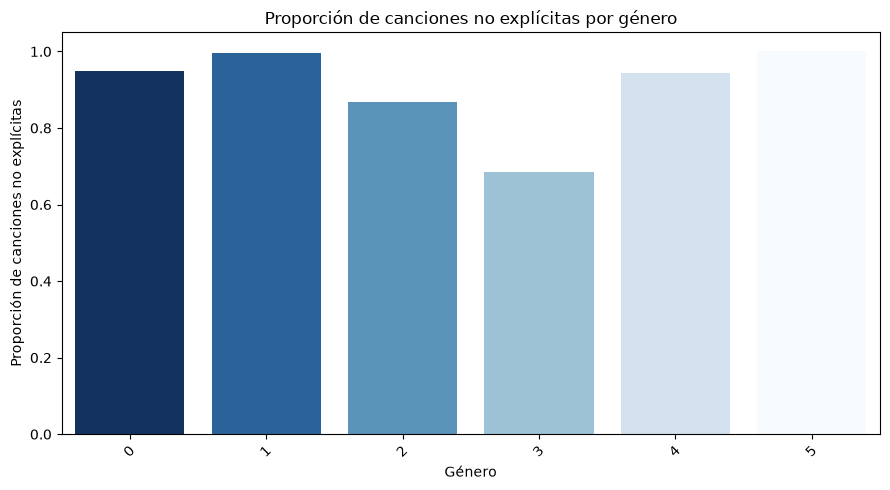

In [120]:
ratio_no_explicitas = (
    dt.groupby("Expected")["explicit"]
      .apply(lambda columna: (~columna).mean())
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=ratio_no_explicitas.index,
    y=ratio_no_explicitas.values,
    hue=ratio_no_explicitas.index,
    palette="Blues_r",
    legend=False
)

plt.title("Proporción de canciones no explícitas por género")
plt.xlabel("Género")
plt.ylabel("Proporción de canciones no explícitas")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#este grafico muestra como el genero de jaz y clasical se destacan en ser los generos con menor contenido explicito.

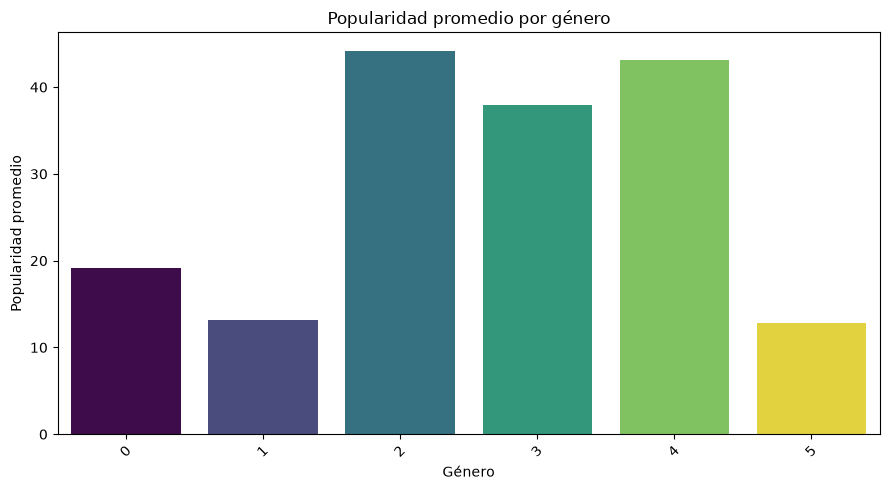

In [121]:

popularidad_genero = (
    dt.groupby("Expected")["popularity"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=popularidad_genero.index,
    y=popularidad_genero.values,
    hue=popularidad_genero.index,
    palette="viridis",
    legend=False
)

plt.title("Popularidad promedio por género")
plt.xlabel("Género")
plt.ylabel("Popularidad promedio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

podemos notar que el genero de electronica y acustico se destacan a diferencia de los otros en la popularidad. mientras que jazz destaca en ser la de menor popularidad

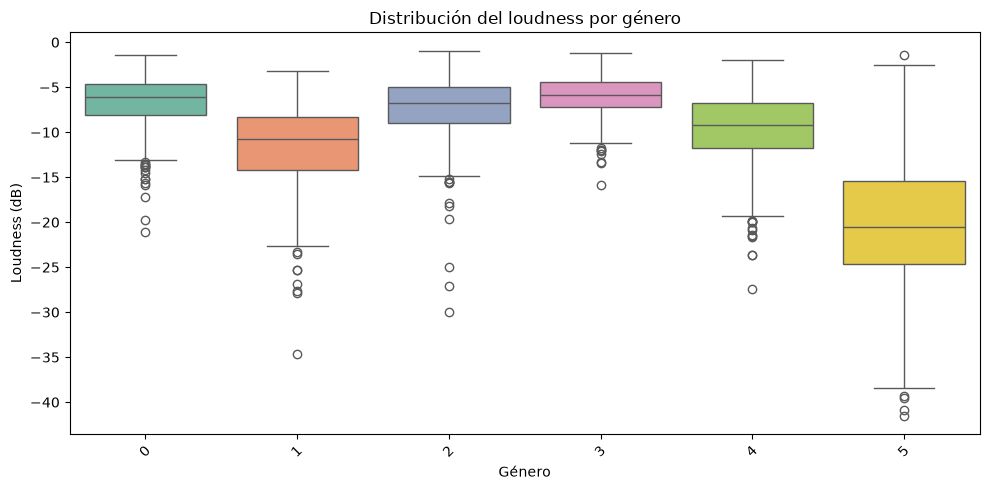

In [122]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=dt,
    x="Expected",
    y="loudness",
    hue="Expected",
    palette="Set2",
    legend=False
)

plt.title("Distribución del loudness por género")
plt.xlabel("Género")
plt.ylabel("Loudness (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

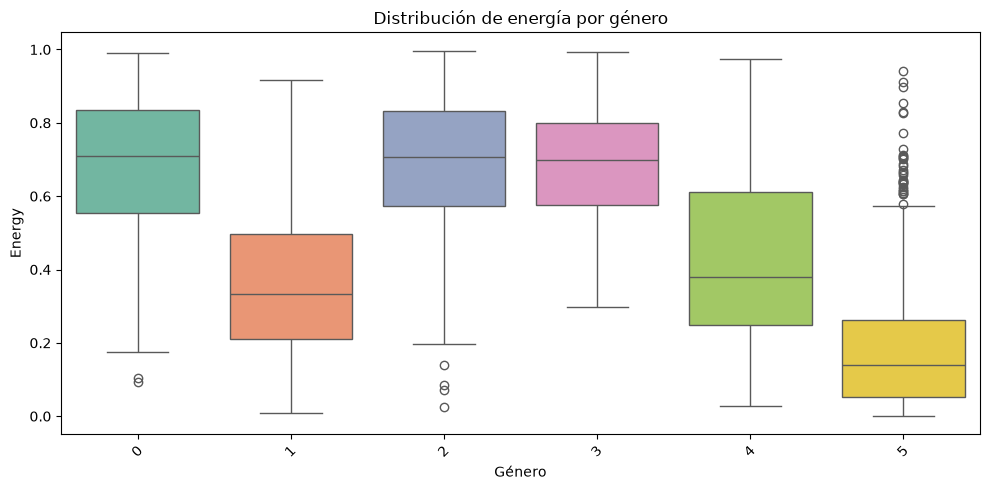

In [123]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=dt,
    x="Expected",
    y="energy",
    hue="Expected",
    palette="Set2",
    legend=False
)

plt.title("Distribución de energía por género")
plt.xlabel("Género")
plt.ylabel("Energy")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#podemos notar que clasical se destaca en canciones mas tranquilas

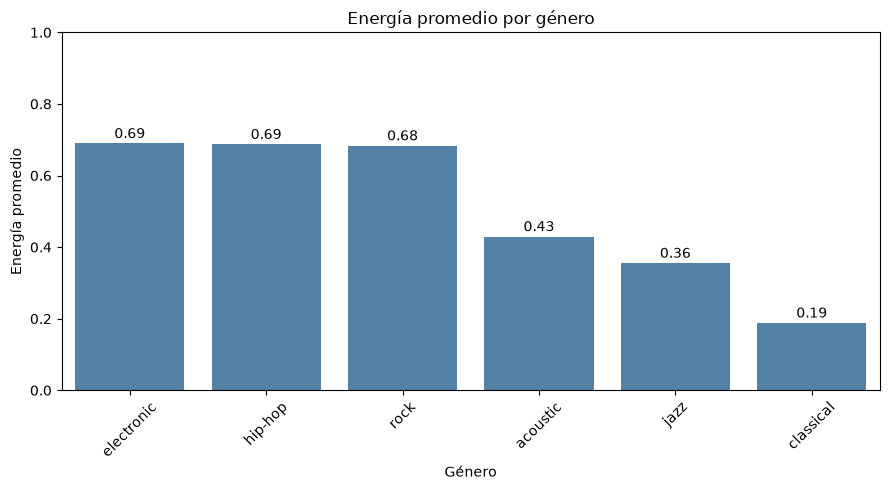

In [124]:
energia_genero = (
    dt.groupby("Expected")["energy"]
      .mean()
      .sort_values(ascending=False)
)

nombres_generos = {
    0: "rock",
    1: "jazz",
    2: "electronic",
    3: "hip-hop",
    4: "acoustic",
    5: "classical"
}

energia_genero.index = energia_genero.index.map(nombres_generos)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=energia_genero.index,
    y=energia_genero.values,
    color="steelblue"
)

plt.title("Energía promedio por género")
plt.xlabel("Género")
plt.ylabel("Energía promedio")
plt.ylim(0, 1)

for i, valor in enumerate(energia_genero.values):
    ax.text(i, valor + 0.015, f"{valor:.2f}", ha="center")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

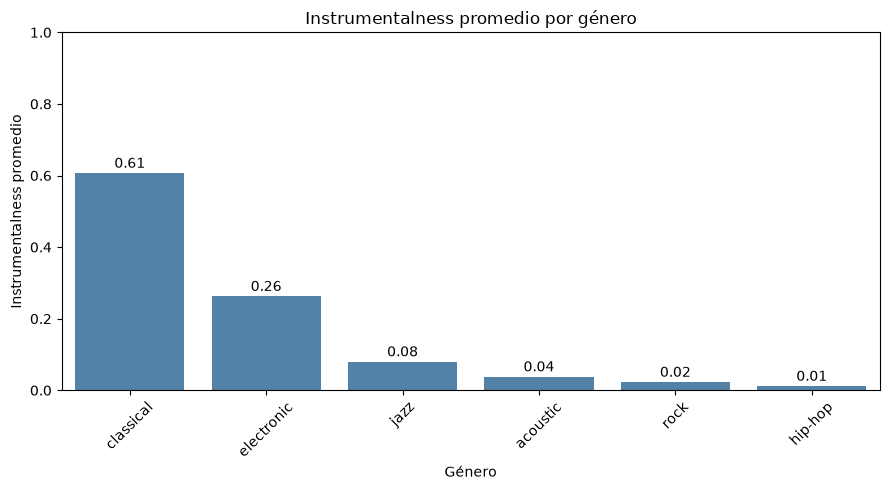

In [125]:
instrumentalness_genero = (
    dt.groupby("Expected")["instrumentalness"]
      .mean()
      .sort_values(ascending=False)
)

nombres_generos = {
    0: "rock",
    1: "jazz",
    2: "electronic",
    3: "hip-hop",
    4: "acoustic",
    5: "classical"
}

instrumentalness_genero.index = instrumentalness_genero.index.map(nombres_generos)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=instrumentalness_genero.index,
    y=instrumentalness_genero.values,
    color="steelblue"
)

plt.title("Instrumentalness promedio por género")
plt.xlabel("Género")
plt.ylabel("Instrumentalness promedio")
plt.ylim(0, 1)

for i, valor in enumerate(instrumentalness_genero.values):
    ax.text(i, valor + 0.015, f"{valor:.2f}", ha="center")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
X_train_temp = pd.read_csv("train.csv")

#variables de entrenamiento
X_train = X_train_temp.drop(columns=["Expected", "Id"])
X_train_XG = X_train_temp.drop(columns=["Expected", "Id"])

y_train = X_train_temp["Expected"] 
#este y_train es para XG
y_train_XG = X_train_temp["Expected"] 
#este y_train es para sin pca
y_train_2 = X_train_temp["Expected"] 

#variables de prediccion
X_test_temp = pd.read_csv("test.csv")
Id = X_test_temp["Id"]          # la guardás para el submission
X_test = X_test_temp.drop(columns=["Id"]) #sacamos "id" ya que no sirve para predecir
X_test_XG = X_test_temp.drop(columns=["Id"]) #X_test para XG


In [127]:
#escalamos y trabajamos los outliers
scaler = RobustScaler()
X_train_1 = scaler.fit_transform(X_train)
X_test_1 = scaler.transform(X_test)


In [128]:
#chequeamos balanceo del dataset
balanceo = y_train.value_counts(normalize=True)
#estan balanceados

In [129]:
#aplicamos reduccion de la dimensionalidad para ajustar mejor los modelos
pca = PCA(n_components=6)
X_train_1 = pca.fit_transform(X_train_1)
X_test_1 = pca.transform(X_test_1)

In [130]:
#utilizamos el primer modelo
modelo = LogisticRegression()
modelo.fit(X_train_1, y_train)
y_pred = modelo.predict(X_test_1)
submission = pd.DataFrame({
    "Id": Id,
    "Expected": y_pred
})
submission

,Id,Expected
0,3793,acoustic
1,5701,acoustic
2,2721,electronic
3,4079,rock
4,479,electronic
...,...,...
1795,4417,classical
1796,1835,rock
1797,3156,hip-hop
1798,1454,hip-hop


In [ ]:
#DESCARGAMOS EL ARCHIVO
#submission.to_csv("submission.csv", index=False)


In [ ]:
#PRUEBA SIN PCA.
scaler_2= RobustScaler()
X_train_2 =  scaler_2.fit_transform(X_train)
X_test_2 =  scaler_2.transform(X_test)

modelo_2 = LogisticRegression()
modelo_2.fit(X_train_2, y_train_2)
y_pred_2 = modelo_2.predict(X_test_2)

submission2 = pd.DataFrame({
    "Id": Id,
    "Expected": y_pred_2
})
#Descargamos el archivo
#submission2.to_csv("prueba_sin_pca.csv", index=False)


c:\Users\arrie\OneDrive - Universidad Torcuato Di Tella\FACULTAD\3er año semestre 2\TD6\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


aca hicimos el modelo de regresion logistica con PCA y sin PCA, vimos que con PCA da muy mal (0.5) y sin PCA da un poco mejor (0.6), de ultima despues podemos explicar pq se da esto o algo asi.

MODELO POSTA

In [ ]:

#pca = PCA(n_components = )
#X_train_XG = pca.fit_transform(X_train)
#X_test_XG = pca.transform(X_test)

parametros = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'learning_rate': [0.01, 0.1, 0.3]
}

XGB = XGBClassifier(
    objective='multi:softmax',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=XGB,
    param_distributions=parametros,
    n_iter=50,          
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_XG, y_train_XG) #prueba combinaciones y deja los mejores hiperparametros en XGB



In [ ]:
#predecimos con XG_boost:
modelo_XG = random_search.best_estimator_
y_pred_XG = modelo_XG.predict(X_test_XG)

archivo_modelo_XG = pd.DataFrame({
    "Id": Id,
    "Expected": y_pred_XG
})

archivo_modelo_XG.to_csv("modelo_XG.csv", index=False)

probar: RandomForest con PCA, XGB con grid search.